# Name
Please write your name down here:

Peter Brederlow

**Exploratory analysis: Mouse strain genotypes**

We will mainly explore some of the data generated by the mouse experiments discussed in the intro lecture, and in more detail in the publications listed below. This will include downloading and importing data, describing the distributions of numerical value columns, and plotting several relationships. The main goal is to familiarize ourselves with the data while getting further practice with `pandas`.

If you are ahead of schedule at any point, feel free to play with the data and explore it from different angles.

The full publication that inspired some of the data analyses steps we'll do in this practical course was published in Science in 2016:

__Systems proteomics of liver mitochondria function__      
by Evan G. Williams, Yibo Wu, Pooja Jha, Sébastien Dubuis et al.     
_Science_     
Volume 352(6291): [aad0189](http://science.sciencemag.org/content/352/6291/aad0189)    
June 10, 2016, [doi:10.1126/science.aad0189](https://doi.org/10.1126/science.aad0189)

The __supplemental files__ are listed here: http://science.sciencemag.org/content/suppl/2016/06/10/352.6291.aad0189.DC1

We further include some methodology discussed in a related paper about mouse-human PheWAS (Phenome wide association studies)

__Joint mouse–human phenome-wide association to test gene function and disease risk__ <br>
by Xusheng Wang, Ashutosh K. Pandey, Megan K. Mulligan, Evan G. Williams et al.     
_Nature Communications_     
Volume 7, Article number: 10464, [doi:10.1038/ncomms10464](https://doi.org/10.1038/ncomms10464)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('future.no_silent_downcasting', True)

/var/folders/vm/8qbbn1f91lb9f4yl4gd82lch0000gn/T/ipykernel_34484/4269531646.py:6: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


# Download Genotype supplement and check if it worked

The genotype data can be found in the supplemental file "aad0189_DataFileS4.txt" or "Data S4". For your convenience, you can also access the data directly from GitHub at `https://github.com/Practical-Integrative-Bioinformatics/00_Introduction/blob/main/data/genotype.txt?raw=true`. Open the file to familiarize yourself with the data format.

# Genotype overview
The mouse genotype data is provided as a tab-delimited text file.

## Load genotype file into a pandas DataFrame `genotype` using the correct read function
Also set `Locus` as the index for this DataFrame.

In [4]:
# YOUR CODE HERE
url = 'https://github.com/Practical-Integrative-Bioinformatics/00_Introduction/blob/main/data/genotype.txt?raw=true'
# genotype = pd.read_csv(url, sep='\t')
# colnames = genotype.iloc[5]
# print(colnames)
# genotype = genotype.iloc[6:]
# genotype.columns = colnames
# genotype

genotype = pd.read_table(url, skiprows=5, header = 1, index_col="Locus")
genotype

,Chr,cM,Mb,BXD1,BXD2,BXD5,BXD6,BXD8,BXD9,BXD11,...,BXD90,BXD91,BXD93,BXD94,BXD95,BXD98,BXD99,BXD100,BXD101,BXD102
Locus,,,,,,,,,,,,,,,,,,,,,
rs6269442,1,0.000,3.482275,B,B,D,D,D,B,B,...,B,D,B,D,D,B,B,B,B,B
rs6365999,1,0.000,4.811062,B,B,D,D,D,B,B,...,B,D,B,D,D,B,B,B,B,U
rs6376963,1,0.895,5.008089,B,B,D,D,D,B,B,...,B,D,B,D,D,B,B,B,B,U
rs3677817,1,1.185,5.176058,B,B,D,D,D,B,B,...,B,D,B,D,D,B,B,B,B,U
rs8236463,1,2.081,5.579193,B,B,D,D,D,B,D,...,B,D,B,D,D,B,B,B,B,U
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CEL-X_154259201,X,71.490,160.727278,B,B,B,D,B,B,B,...,B,B,D,D,H,D,D,B,U,U
rs3657281,X,71.776,160.951099,B,B,B,D,B,B,B,...,B,B,D,D,H,D,D,B,U,U
rs13484106,X,71.776,162.637897,B,B,B,D,B,B,B,...,B,B,D,D,H,D,D,B,U,U


In [5]:
assert 'genotype' in locals()

### Describe what the individuals rows and columns in the dataframe mean
You may have to have a look at the file header of the genotype file as well as the data repositories containing genetic data of mice: http://gn1.genenetwork.org/mouseCross.html and http://gn1.genenetwork.org/webqtl/main.py?FormID=sharinginfo&GN_AccessionId=600 

| Category | Name | Description |
|----------|------|-------------|
| Rows | BX… strains | Each row represents an inbred mouse strain (e.g., BXD strains). Each entry shows the genotype of that strain at a specific locus. |
| Columns | Locus | Name of the genetic locus. |
| Columns | Chromosome (Chr) | Chromosomal location of the specified locus. |
| Columns | Centimorgan (cM) | Genetic distance from the first locus on the chromosome. 1 cM corresponds to a 1% recombination probability. |
| Columns | Megabases (Mb) | Physical distance (in millions of base pairs) from the first locus on the chromosome. |
| Cells | Genotype | The genotype of a given mouse strain at a specific locus. |

### How many SNPs are defined in the genotype file?
Store the answer in `n_snp`.

In [6]:
# YOUR CODE HERE
n_snp = genotype.shape[0]
n_snp

3811

In [7]:
assert 'n_snp' in locals()

### How many different strains are included in the genotype file?
Store the answer in `n_strains`.

In [8]:
# YOUR CODE HERE
# n_strains = genotype.shape[1] - 3
# n_strains

n_strains = sum(col.startswith('BX') for col in genotype.columns)
n_strains

93

In [9]:
assert 'n_strains' in locals()

### Separate the genotype metadata from the genotype data

Create two DataFrames called `geno_meta` and `geno_bdh` by slicing the `genotype` DataFrame's columns accordingly. All the genotype identifiers and chromosomal positions should go in `geno_meta`, and the strain genotypes to `geno_bdh`.

In [10]:
# YOUR CODE HERE
geno_meta = genotype.iloc[:, :3]
geno_meta

,Chr,cM,Mb
Locus,,,
rs6269442,1,0.000,3.482275
rs6365999,1,0.000,4.811062
rs6376963,1,0.895,5.008089
rs3677817,1,1.185,5.176058
rs8236463,1,2.081,5.579193
...,...,...,...
CEL-X_154259201,X,71.490,160.727278
rs3657281,X,71.776,160.951099
rs13484106,X,71.776,162.637897


In [11]:
geno_bdh = genotype.iloc[:, 3:]
geno_bdh

,BXD1,BXD2,BXD5,BXD6,BXD8,BXD9,BXD11,BXD12,BXD13,BXD14,...,BXD90,BXD91,BXD93,BXD94,BXD95,BXD98,BXD99,BXD100,BXD101,BXD102
Locus,,,,,,,,,,,,,,,,,,,,,
rs6269442,B,B,D,D,D,B,B,D,B,B,...,B,D,B,D,D,B,B,B,B,B
rs6365999,B,B,D,D,D,B,B,D,B,B,...,B,D,B,D,D,B,B,B,B,U
rs6376963,B,B,D,D,D,B,B,D,B,B,...,B,D,B,D,D,B,B,B,B,U
rs3677817,B,B,D,D,D,B,B,D,B,B,...,B,D,B,D,D,B,B,B,B,U
rs8236463,B,B,D,D,D,B,D,D,B,B,...,B,D,B,D,D,B,B,B,B,U
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CEL-X_154259201,B,B,B,D,B,B,B,B,D,B,...,B,B,D,D,H,D,D,B,U,U
rs3657281,B,B,B,D,B,B,B,B,D,B,...,B,B,D,D,H,D,D,B,U,U
rs13484106,B,B,B,D,B,B,B,B,D,B,...,B,B,D,D,H,D,D,B,U,U


In [12]:
assert 'geno_meta' in locals()
assert 'geno_bdh' in locals()

# Plot the distribution patterns of maternal and paternal alleles across strains and SNPs

## Plot the distributions of B and D alleles per mouse strain in a stacked bar chart

The bar chart should have as many bars as mouse strains. Each bar should reflect how many B, D, H and U alleles that particular mouse strain has. For this, you will first have to find a way to count the number of occurences of each label in each column of the `geno_bdh` DataFrame.


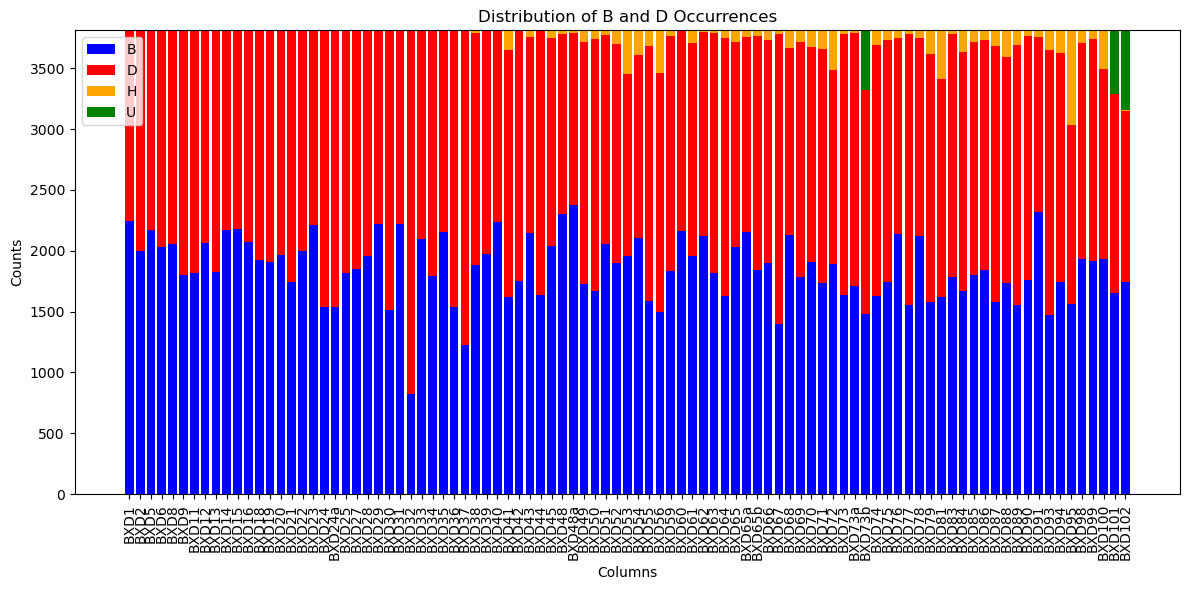

In [13]:
# YOUR CODE HERE
b_counts = geno_bdh.apply(lambda col: (col == 'B').sum())
d_counts = geno_bdh.apply(lambda col: (col == 'D').sum())
h_counts = geno_bdh.apply(lambda col: (col == 'H').sum())
u_counts = geno_bdh.apply(lambda col: (col == 'U').sum())

plt.figure(figsize=(12, 6))
columns = geno_bdh.columns
plt.bar(columns, b_counts, label='B', color='blue')
plt.bar(columns, d_counts, bottom=b_counts, label='D', color='red')
plt.bar(columns, h_counts, bottom=b_counts + d_counts, label='H', color='orange')
plt.bar(columns, u_counts, bottom=b_counts + d_counts + h_counts, label='U', color='green')
plt.xlabel('Columns')
plt.ylabel('Counts')
plt.title('Distribution of B and D Occurrences')
plt.legend()
plt.xticks(rotation=90)  
plt.tight_layout()
plt.show()


## Plot the proportion of B alleles per SNP in a histogram

We know that the B/D alleles are evenly split in the offspring mice, but we don't know whether they are also evenly split across different SNPs. Just because the mice are ~50-50% B/H doesn't mean there aren't genomic positions where they are all `B` or all `H`. To investigate, create a histogram from the proportion of `B` alleles of each SNP.

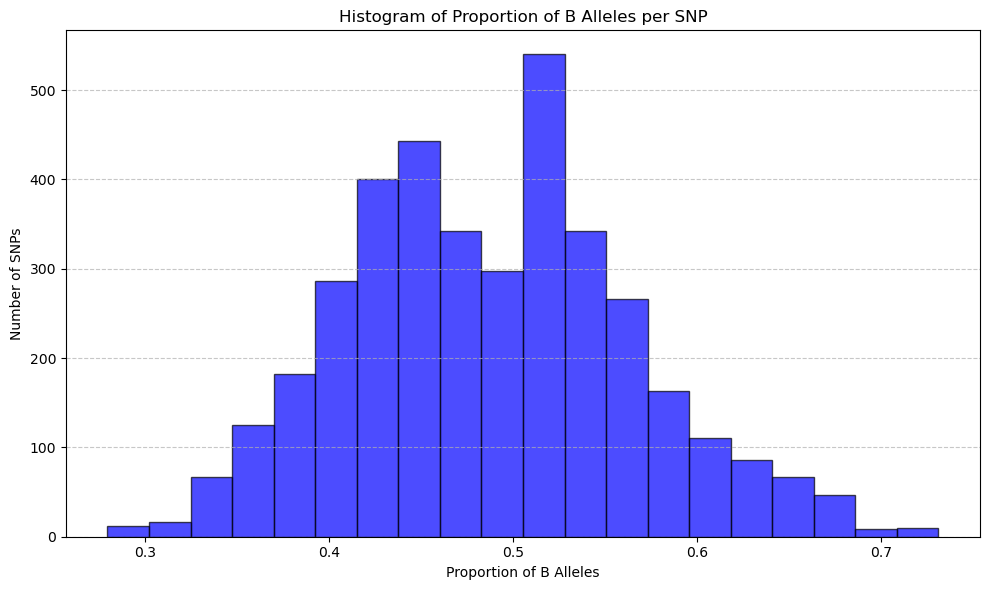

In [14]:
# YOUR CODE HERE
b_proportions = geno_bdh.apply(lambda row: (row == 'B').sum() / len(row), axis=1)

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(b_proportions, bins=20, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel('Proportion of B Alleles')
plt.ylabel('Number of SNPs')
plt.title('Histogram of Proportion of B Alleles per SNP')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot the strain genotypes on a heatmap

We want to have a visual representation of how thoroughly the genomes of the original B and D strains have been mixed in their inbred offspring. A heatmap (a color-coded image of a matrix) would be suitable for this task. However, we have to help out the plotting libraries by converting letters into numbers so that they can be visualized with a color scale.

## Step 1: convert `geno_bdh`'s values to numbers and store it in a DataFrame named `geno`
There are four different kinds of genotypes: homozygous B, homozygous D, heterozygous (H) and unknown (U).

A logical conversion would be placing the heterozygous value between the homozygous values, hence:

|strain| value  |
|------|--------|
|  B   |  0.0     |
|  H   |  1.0     |
|  D   |  2.0     |
|  U   | missing (NaN)|

In [15]:
# YOUR CODE HERE
geno = geno_bdh.replace({'B': 0.0, 'H': 1.0, 'D': 2.0, 'U': np.nan})
geno = geno.astype(float)
geno

,BXD1,BXD2,BXD5,BXD6,BXD8,BXD9,BXD11,BXD12,BXD13,BXD14,...,BXD90,BXD91,BXD93,BXD94,BXD95,BXD98,BXD99,BXD100,BXD101,BXD102
Locus,,,,,,,,,,,,,,,,,,,,,
rs6269442,0.0,0.0,2.0,2.0,2.0,0.0,0.0,2.0,0.0,0.0,...,0.0,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0
rs6365999,0.0,0.0,2.0,2.0,2.0,0.0,0.0,2.0,0.0,0.0,...,0.0,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,NaN
rs6376963,0.0,0.0,2.0,2.0,2.0,0.0,0.0,2.0,0.0,0.0,...,0.0,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,NaN
rs3677817,0.0,0.0,2.0,2.0,2.0,0.0,0.0,2.0,0.0,0.0,...,0.0,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,NaN
rs8236463,0.0,0.0,2.0,2.0,2.0,0.0,2.0,2.0,0.0,0.0,...,0.0,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CEL-X_154259201,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,...,0.0,0.0,2.0,2.0,1.0,2.0,2.0,0.0,NaN,NaN
rs3657281,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,...,0.0,0.0,2.0,2.0,1.0,2.0,2.0,0.0,NaN,NaN
rs13484106,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,...,0.0,0.0,2.0,2.0,1.0,2.0,2.0,0.0,NaN,NaN


In [16]:
assert 'geno' in locals()

## Step 2: Create a heatmap from the (now numeric) genotype DataFrame

Make sure that the plot is large enough.

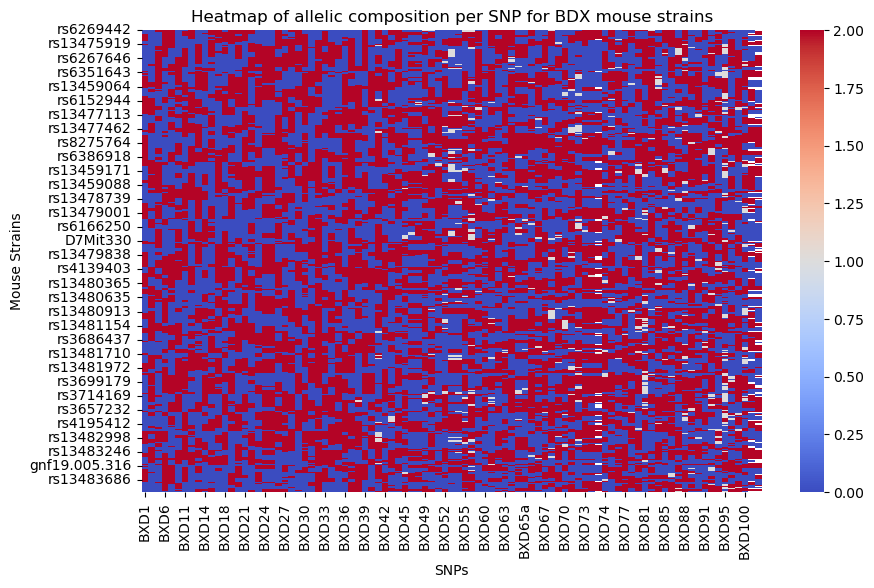

In [17]:
# YOUR CODE HERE
#plotting
plt.figure(figsize=(10, 6))
sns.heatmap(geno, cmap="coolwarm", cbar=True, annot=False)
plt.title("Heatmap of allelic composition per SNP for BDX mouse strains")
plt.xlabel("SNPs")
plt.ylabel("Mouse Strains")
plt.show()

## Step 3: Cluster the strains based on their genotype similarity

A clustered heatmap is a heatmap with rearranged rows and/or columns, usually with an accompanying dendrogram next to the heatmap, reflecting the similarity of the rows/columns, and the steps of the hierarchical clustering. `seaborn` can do all the heavy lifting for you.

You may run into trouble with missing data: you can choose to discard them selectively, or fill them with a dummy value (the heterozygous genotype's `1` being the least bad choice).

Do you think clustering SNPs makes sense here? If not, how do you turn it off?

/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


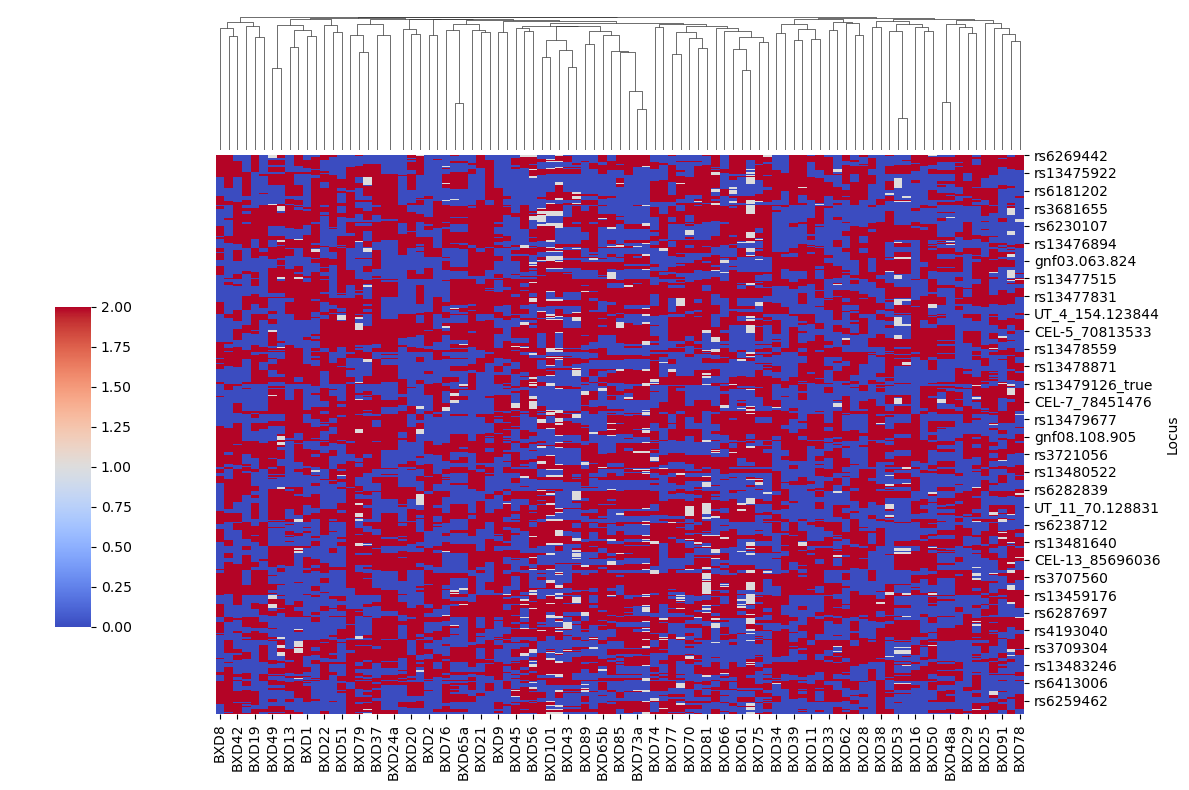

In [18]:
# YOUR CODE HERE
geno_filled = geno.fillna(1.0)
sns.clustermap(
    geno_filled,
    cmap="coolwarm",
    col_cluster=True,  
    row_cluster=False,  
    figsize=(12, 8),
    cbar_pos=(0.05, 0.21, 0.03, 0.4)  
)
plt.show()

**Do you find anything visually interesting in the results? How do you interpret it?**

The data looks very noisy, and there is not a very intricate structure in the clusterings, although the genotypes seem to form small clusters. In those clusters, there is no clear relation between the numbers of the genotypes and the cluster assortment.

# Export the `geno_meta` and `geno` DataFrames in `tsv` files for later use

In [19]:
# YOUR CODE HERE
geno_meta.to_csv('geno_meta.tsv', sep='\t', index=False)
geno.to_csv('geno.tsv', sep='\t', index=False)

# Bonus task: calulcate genotype similarity between two mouse strains of your choice

The scale could range from 0 (completely different) to 1 (fully identical). You can even do all-vs-all if you want to, and report the pair with the highest and lowest similarity. You can also plot a histogram of the pairwise similarities of all mouse strain pairs.

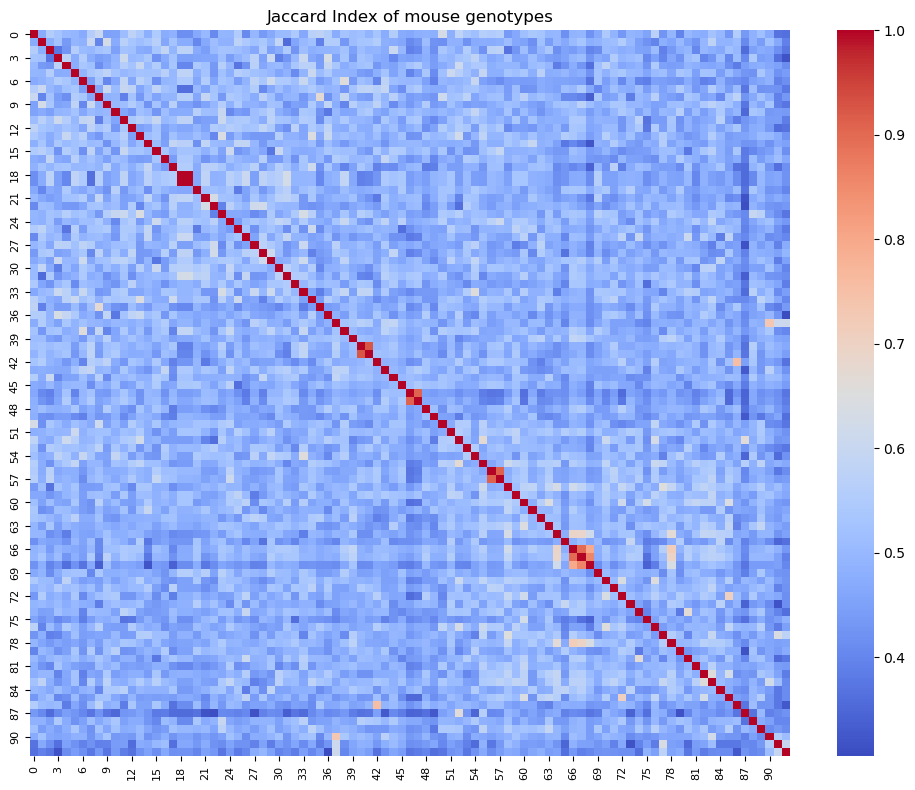

In [20]:
# YOUR CODE HERE
#compute the jaccard index of the strains -> number of shared alleles / number of total alleles for each pair
#does treat hemizygosity similar to completely different alleles
jaccard_matrix = np.zeros((n_strains, n_strains))
for i in range(n_strains):
    for j in range(n_strains):
        strain1 = geno_filled.iloc[:, i]
        strain2 = geno_filled.iloc[:, j]
        intersection = ((strain1 == strain2) & ~strain1.isna() & ~strain2.isna()).sum()
        union = ((~strain1.isna()) | (~strain2.isna())).sum()
        jaccard_matrix[i, j] = intersection / union if union > 0 else np.nan
jaccard_df = pd.DataFrame(jaccard_matrix, index=geno_filled.columns, columns=geno_filled.columns)


plt.figure(figsize=(10, 8))
sns.heatmap(jaccard_matrix, cmap="coolwarm", cbar=True)
plt.title("Jaccard Index of mouse genotypes")
plt.xticks(rotation=90, fontsize=8) 
plt.yticks(fontsize=8) 
plt.tight_layout()
plt.show()

In [21]:
#get maximal similar strains
overall_max = jaccard_df.where(jaccard_df < 1.0).stack().idxmax()
overall_max_value = jaccard_df.loc[overall_max]
overall_max

('BXD48', 'BXD48a')

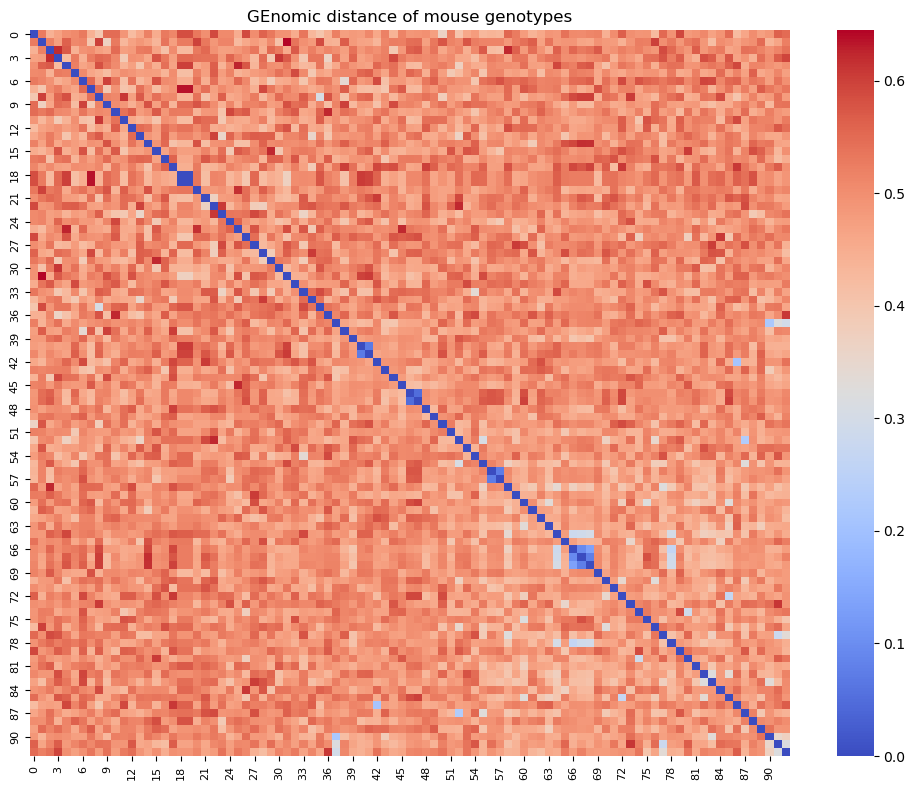

In [24]:
#custom metric
#verrrryyyyy bad in runtime, but it accounts for hemizygosity and missing data in a more nuanced way than Jaccard
custom_matrix = np.zeros((n_strains, n_strains))
for i in range(n_strains):
    for j in range(n_strains):
        dist = 0
        for q in range(geno_filled.shape[0]):
            if not pd.isna(geno_filled.iloc[q, i]) and not pd.isna(geno_filled.iloc[q, j]): #else just skip
                dist += abs(geno_filled.iloc[q, i] - geno_filled.iloc[q, j])
        max_dist = ((~strain1.isna()) | (~strain2.isna())).sum() * 2 #accounts for skips, when one is missing
        custom_matrix[i, j] = dist / max_dist 

plt.figure(figsize=(10, 8))
sns.heatmap(custom_matrix, cmap="coolwarm", cbar=True)
plt.title("GEnomic distance of mouse genotypes")
plt.xticks(rotation=90, fontsize=8) 
plt.yticks(fontsize=8) 
plt.tight_layout()
plt.show()